In [1]:
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import torch
from torch.utils.data import DataLoader

from neuralhydrology.datasetzoo import get_dataset, lamah
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.modelzoo.ealstm import EALSTM
from neuralhydrology.modelzoo.customlstm import CustomLSTM
from neuralhydrology.nh_run import eval_run
from neuralhydrology.utils.config import Config

In [2]:
nse_dict = {}

In [3]:
run_dir_path = Path("/home/wuhlmann/BA/test_runs/runs/test_256_1024_1811_133845")

attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
basin_stca_gdf = gpd.read_file(attributes_shape_path)
basin_stca_gdf.set_index("ID", inplace=True)

for phase in ["train", "validation", "test"]:

    metrics_path = run_dir_path / f"{phase}/model_epoch030/{phase}_metrics.csv" 

    metrics = pd.read_table(metrics_path, header=0, sep=",")

    nse_dict[phase] = metrics
        


train NSE median is 0.8344173431396484


/tmp/ipykernel_2332520/4077894060.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  highlight.plot(ax=ax, color="red")


<Axes: >

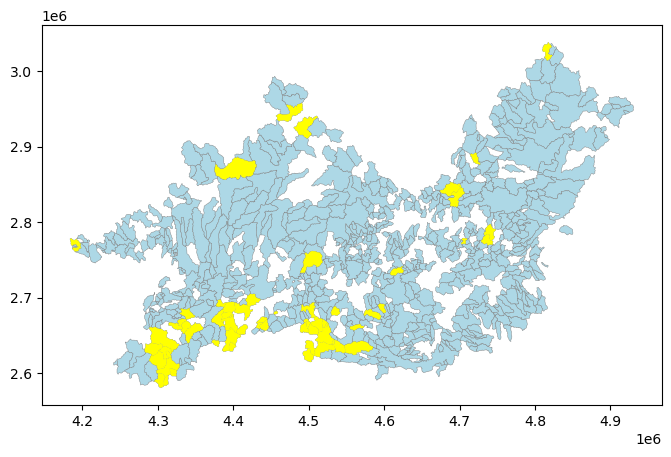

In [4]:
phase = "train"

fig, ax = plt.subplots(figsize=(8, 8))

df = nse_dict[phase]

print(f"{phase} NSE median is {df['NSE'].median()}")

sub_0_basins = df[df["NSE"] < 0]
over_08_basins = df[df["NSE"]>0.9]["basin"].values

test_basins = basin_stca_gdf.loc[df["basin"].values]
test_basins.plot(ax=ax, color="lightblue", edgecolor="gray", linewidth=0.3)
highlight = basin_stca_gdf.loc[sub_0_basins["basin"].values]
highlight.plot(ax=ax, color="red")
highlight = basin_stca_gdf.loc[over_08_basins]
highlight.plot(ax=ax, color="yellow")

train NSE median 0.834 | mean 0.816
0 basins with NSE < 0 | 0.00%
63 basins with NSE > 0.9 | 9.42%
validation NSE median 0.607 | mean 0.005
16 basins with NSE < 0 | 18.82%
0 basins with NSE > 0.9 | 0.00%
test NSE median 0.575 | mean 0.354
11 basins with NSE < 0 | 12.64%
1 basins with NSE > 0.9 | 1.15%


<Axes: >

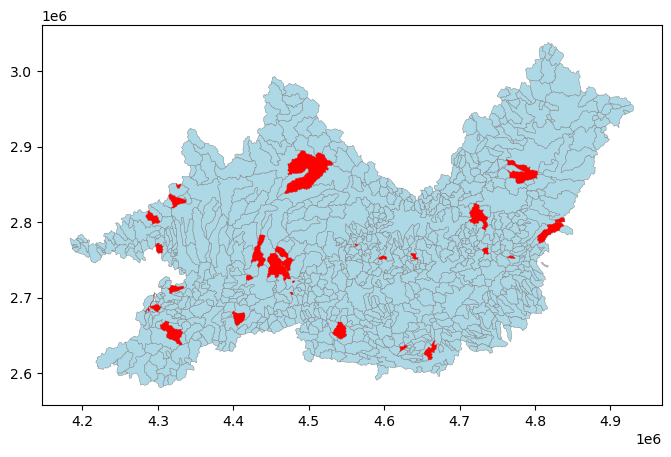

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

sub_0_basins = []
over_08_basins = []

for phase, df in nse_dict.items():

    print(f"{phase} NSE median {df['NSE'].median():.3f} | mean {df['NSE'].mean():.3f}")

    phase_sub_0 = df[df["NSE"]<0]["basin"].values
    phase_over_08 = df[df["NSE"]>0.9]["basin"].values

    print(f"{len(phase_sub_0)} basins with NSE < 0 | {len(phase_sub_0)/len(df)*100:.2f}%")
    print(f"{len(phase_over_08)} basins with NSE > 0.9 | {len(phase_over_08)/len(df)*100:.2f}%")

    sub_0_basins.extend(phase_sub_0)
    over_08_basins.extend(phase_over_08)


basin_stca_gdf.plot(ax=ax, color="lightblue", edgecolor="gray", linewidth=0.3)
highlight = basin_stca_gdf.loc[over_08_basins]
# highlight.plot(ax=ax, color="yellow")
highlight = basin_stca_gdf.loc[sub_0_basins]
highlight.plot(ax=ax, color="red")


In [2]:
import pickle as pkl

with open("/home/wuhlmann/BA/data/processed_data/test_splits/test_full_q.pkl", "rb") as f: 
    train_dict = pkl.load(f)

train_dict["116"]

{'start_dates': [Timestamp('1987-01-01 00:00:00')],
 'end_dates': [Timestamp('2017-12-31 00:00:00')]}